# 3D object detection using 2D HID BEV and YOLOv8 algorithm

In [ ]:
!pip install -r requirements.txt

## Imports

In [2]:
import os
import math
import random
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

velodyne_dir = r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\data\data_object_velodyne\training\velodyne"
label_dir    = r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\data\data_object_label_2\training\label_2"
calib_dir    = r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\data\data_object_calib\training\calib"

out_root = r"C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\kitti_bev_yolo_car"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("OK")

OK


## Configurations

In [3]:
BEV_CFG = {
    # ROI for BEV image
    "x_range": (0.0, 70.0),
    "y_range": (-40.0, 40.0),
    "z_range": (-3.0, 1.0),

    # resolution
    "res": 0.10,

    "use_intensity": True,

    "density_norm": 64.0,  
}

def compute_bev_meta(cfg):
    x_min, x_max = cfg["x_range"]
    y_min, y_max = cfg["y_range"]
    res = cfg["res"]

    H = int(np.ceil((x_max - x_min) / res))  
    W = int(np.ceil((y_max - y_min) / res))  
    return {"H": H, "W": W, **cfg}

meta0 = compute_bev_meta(BEV_CFG)
meta0

{'H': 700,
 'W': 800,
 'x_range': (0.0, 70.0),
 'y_range': (-40.0, 40.0),
 'z_range': (-3.0, 1.0),
 'res': 0.1,
 'use_intensity': True,
 'density_norm': 64.0}

## Load point clouds

In [4]:
def load_kitti_bin(bin_path):
    pts = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)  # x,y,z,intensity
    return pts

def read_kitti_calib(calib_path):
    data = {}
    with open(calib_path, "r") as f:
        for line in f:
            if ":" not in line:
                continue
            key, val = line.split(":", 1)
            vals = np.array([float(x) for x in val.strip().split()], dtype=np.float64)
            data[key.strip()] = vals

    R0 = data["R0_rect"].reshape(3, 3)
    R0_4 = np.eye(4, dtype=np.float64)
    R0_4[:3, :3] = R0

    Tr = data["Tr_velo_to_cam"].reshape(3, 4)
    Tr_4 = np.eye(4, dtype=np.float64)
    Tr_4[:3, :4] = Tr

    return R0_4, Tr_4

def inverse_rigid_transform(T):
    R = T[:3, :3]
    t = T[:3, 3]
    T_inv = np.eye(4, dtype=np.float64)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ t
    return T_inv

def transform_points(T, pts_xyz):
    N = pts_xyz.shape[0]
    pts_h = np.hstack([pts_xyz, np.ones((N, 1), dtype=np.float64)])
    out = (T @ pts_h.T).T
    return out[:, :3]

def rect_to_velo_transform(calib_path):
    R0_4, Tr_velo_to_cam_4 = read_kitti_calib(calib_path)
    T_velo_to_rect = R0_4 @ Tr_velo_to_cam_4
    T_rect_to_velo = inverse_rigid_transform(T_velo_to_rect)
    return T_rect_to_velo

## Load labels

In [5]:
def load_kitti_labels_cars_only(label_path):
    objs = []
    with open(label_path, "r") as f:
        for line in f:
            p = line.strip().split()
            cls = p[0]
            if cls == "DontCare":
                continue
            if cls != "Car":
                continue

            h, w, l = map(float, p[8:11])
            x, y, z = map(float, p[11:14])
            ry = float(p[14])
            objs.append({"cls": cls, "h": h, "w": w, "l": l, "x": x, "y": y, "z": z, "ry": ry})
    return objs

def corners_3d_in_camera(h, w, l, x, y, z, ry):
    x_corners = np.array([ l/2,  l/2, -l/2, -l/2,  l/2,  l/2, -l/2, -l/2])
    y_corners = np.array([ 0.0,  0.0,  0.0,  0.0, -h,   -h,   -h,   -h  ])
    z_corners = np.array([ w/2, -w/2, -w/2,  w/2,  w/2, -w/2, -w/2,  w/2])

    cos_r = math.cos(ry)
    sin_r = math.sin(ry)
    R = np.array([
        [ cos_r, 0.0, sin_r],
        [ 0.0,   1.0, 0.0  ],
        [-sin_r, 0.0, cos_r]
    ], dtype=np.float64)

    corners = np.vstack([x_corners, y_corners, z_corners])  # 3x8
    corners = (R @ corners).T  # 8x3

    corners[:, 0] += x
    corners[:, 1] += y
    corners[:, 2] += z
    return corners

def corners_rectcam_to_velo(obj, T_rect_to_velo):
    corners_cam = corners_3d_in_camera(obj["h"], obj["w"], obj["l"],
                                       obj["x"], obj["y"], obj["z"], obj["ry"])
    corners_velo = transform_points(T_rect_to_velo, corners_cam)
    return corners_velo

## Generating BEV

In [6]:
def make_bev_hid(points_xyzi, meta):
    x_min, x_max = meta["x_range"]
    y_min, y_max = meta["y_range"]
    z_min, z_max = meta["z_range"]
    res = meta["res"]
    H, W = meta["H"], meta["W"]

    pts = points_xyzi

    # filter ROI in xyz
    mask = (
        (pts[:,0] >= x_min) & (pts[:,0] < x_max) &
        (pts[:,1] >= y_min) & (pts[:,1] < y_max) &
        (pts[:,2] >= z_min) & (pts[:,2] < z_max)
    )
    pts = pts[mask]
    if pts.shape[0] == 0:
        return np.zeros((H, W, 3), dtype=np.float32)

    cols = np.floor((pts[:,1] - y_min) / res).astype(np.int32)
    cols = np.clip(cols, 0, W-1)

    rows_unflipped = np.floor((pts[:,0] - x_min) / res).astype(np.int32)
    rows_unflipped = np.clip(rows_unflipped, 0, H-1)
    rows = (H - 1) - rows_unflipped

    # Initialize
    height_map = np.zeros((H, W), dtype=np.float32)
    intensity_map = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.int32)

    # For max ops, start with very low
    height_map[:] = -1e9
    intensity_map[:] = 0.0

    z = pts[:,2].astype(np.float32)
    it = pts[:,3].astype(np.float32)

    # accumulate
    for r, c, zz, ii in zip(rows, cols, z, it):
        if zz > height_map[r, c]:
            height_map[r, c] = zz
        if ii > intensity_map[r, c]:
            intensity_map[r, c] = ii
        count[r, c] += 1

    # normalize height
    empty = (height_map < -1e8)
    height_map[empty] = z_min
    height_map = (height_map - z_min) / max(1e-6, (z_max - z_min))
    height_map = np.clip(height_map, 0.0, 1.0)

    # intensity normalization (clip)
    intensity_map = np.clip(intensity_map, 0.0, 1.0)

    # density log normalization
    Nmax = float(meta.get("density_norm", 64.0))
    density_map = np.log(count.astype(np.float32) + 1.0) / np.log(Nmax)
    density_map = np.clip(density_map, 0.0, 1.0)

    bev = np.stack([height_map, intensity_map, density_map], axis=-1).astype(np.float32)
    return bev

def bev_to_uint8_rgb(bev_float):
    return (np.clip(bev_float, 0.0, 1.0) * 255.0).astype(np.uint8)

In [7]:
def corners_velo_to_bev_xyxy_pixels(corners_velo, meta):
    x_min_m, x_max_m = meta["x_range"]
    y_min_m, y_max_m = meta["y_range"]
    res = meta["res"]
    H, W = meta["H"], meta["W"]

    xy = corners_velo[:, :2]  

    bx0, bx1 = xy[:, 0].min(), xy[:, 0].max()
    by0, by1 = xy[:, 1].min(), xy[:, 1].max()
    if (bx1 < x_min_m) or (bx0 > x_max_m) or (by1 < y_min_m) or (by0 > y_max_m):
        return None

    cols = (xy[:, 1] - y_min_m) / res

    rows_unflipped = (xy[:, 0] - x_min_m) / res
    rows = (H - 1) - rows_unflipped

    x1 = float(np.min(cols))
    x2 = float(np.max(cols))
    y1 = float(np.min(rows))
    y2 = float(np.max(rows))

    # clamp
    x1 = float(np.clip(x1, 0, W - 1))
    x2 = float(np.clip(x2, 0, W - 1))
    y1 = float(np.clip(y1, 0, H - 1))
    y2 = float(np.clip(y2, 0, H - 1))

    # too small -> skip
    if (x2 - x1) < 2 or (y2 - y1) < 2:
        return None

    return (x1, y1, x2, y2)


def xyxy_to_yolo_norm(x1, y1, x2, y2, W, H):
    cx = (x1 + x2) * 0.5
    cy = (y1 + y2) * 0.5
    bw = (x2 - x1)
    bh = (y2 - y1)

    cx = np.clip(cx, 0, W - 1)
    cy = np.clip(cy, 0, H - 1)
    bw = np.clip(bw, 0, W)
    bh = np.clip(bh, 0, H)

    return cx / W, cy / H, bw / W, bh / H

## Preparing Dataset

In [8]:
def list_frame_ids(velodyne_dir):
    ids = sorted([Path(p).stem for p in Path(velodyne_dir).glob("*.bin")])
    return ids

all_ids = list_frame_ids(velodyne_dir)
print("Total frames:", len(all_ids), "Example:", all_ids[:3], all_ids[-3:])

# Split by ID order: 70/15/15
n = len(all_ids)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
train_ids = all_ids[:n_train]
val_ids   = all_ids[n_train:n_train+n_val]
test_ids  = all_ids[n_train+n_val:]

print(len(train_ids), len(val_ids), len(test_ids))

Total frames: 7481 Example: ['000000', '000001', '000002'] ['007478', '007479', '007480']
5236 1122 1123


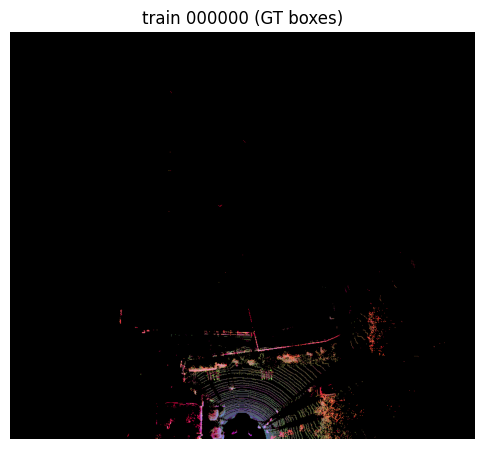

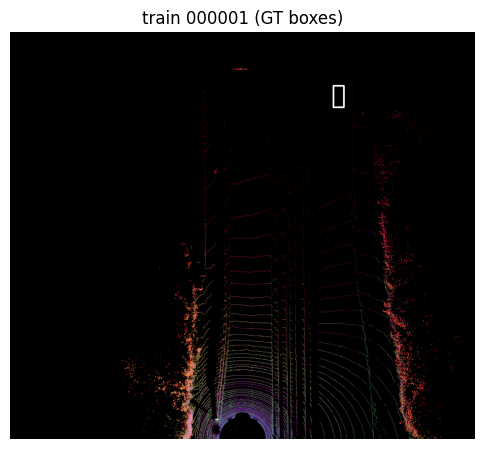

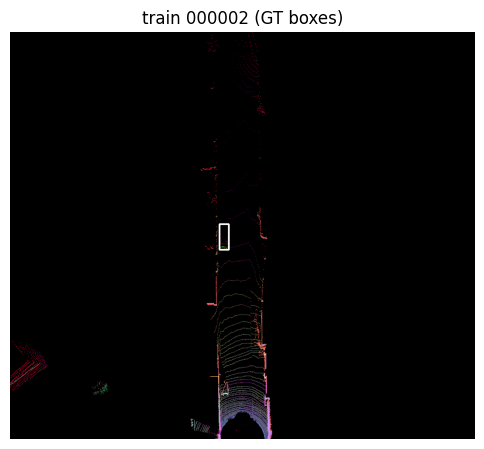

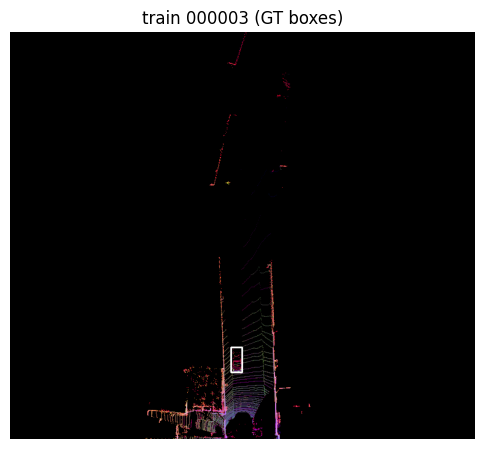

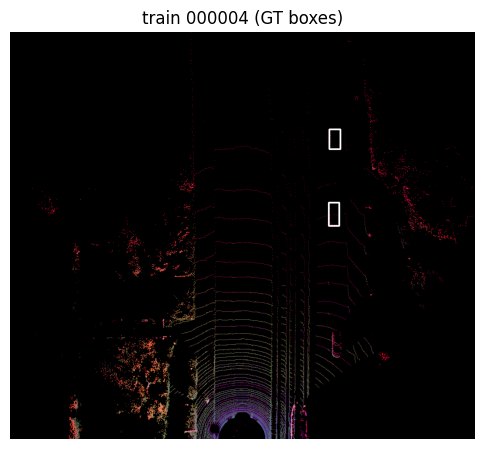

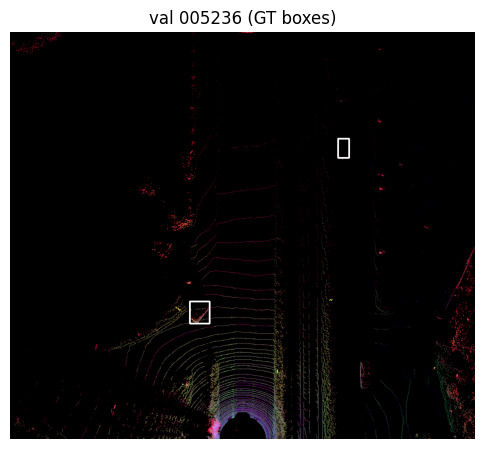

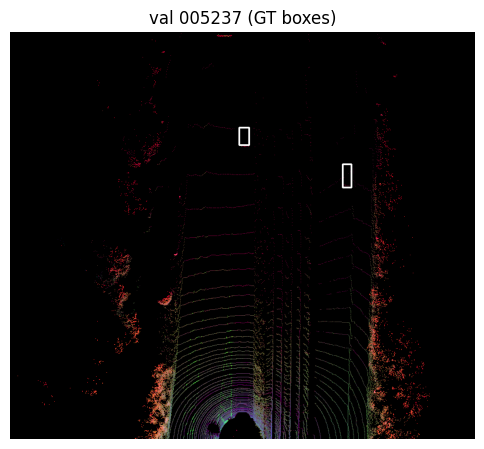

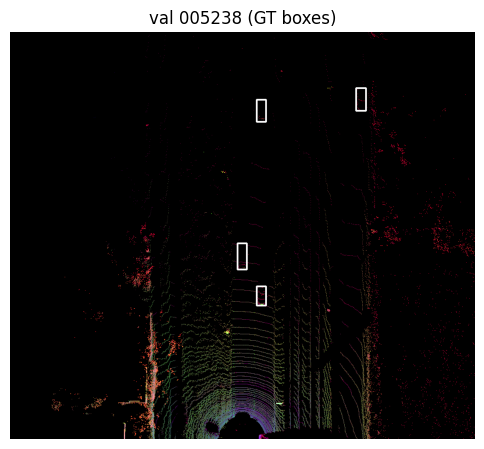

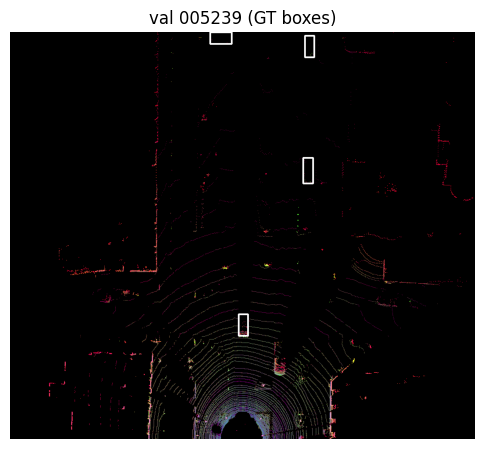

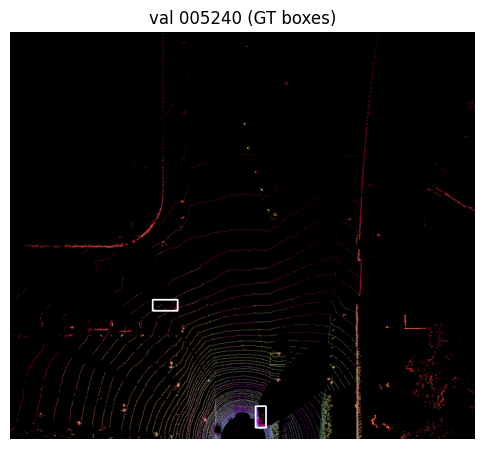

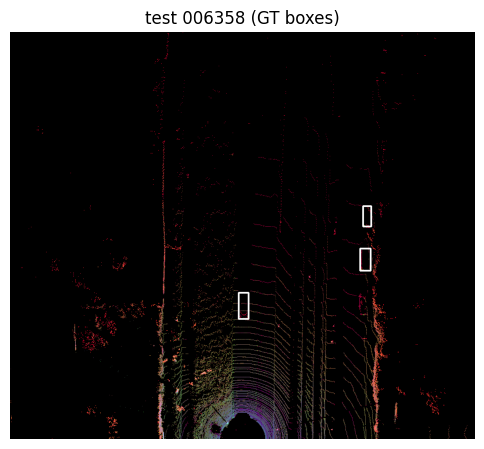

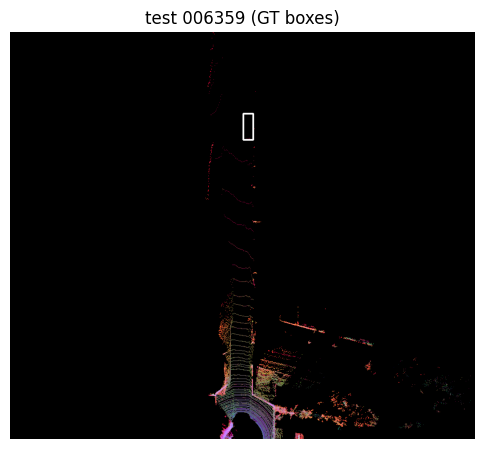

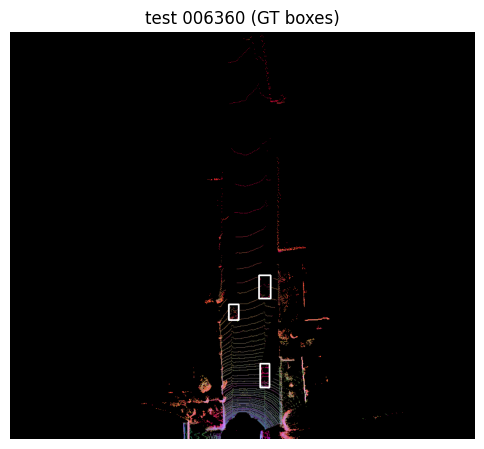

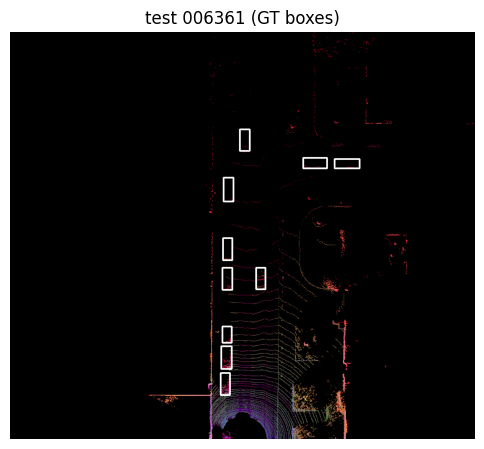

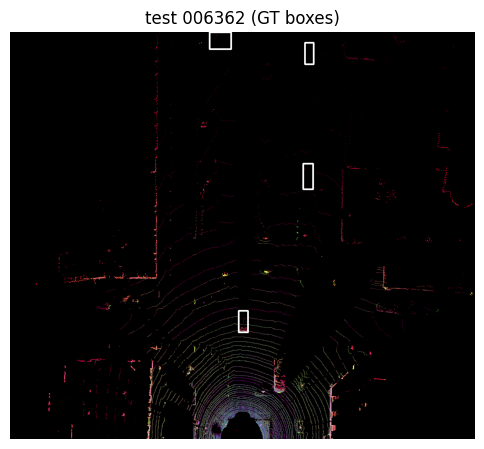

Dataset yaml: C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\kitti_bev_yolo_car\kitti_bev_car.yaml
BEV size HxW: 700 800


In [9]:
def build_yolo_bev_dataset_car_only(
    velodyne_dir, label_dir, calib_dir,
    out_root,
    train_ids, val_ids, test_ids,
    meta,
    overwrite=False,
    vis_debug=False,
    debug_count=5
):
    out_root = Path(out_root)
    img_train = out_root / "images" / "train"
    img_val   = out_root / "images" / "val"
    img_test  = out_root / "images" / "test"
    lab_train = out_root / "labels" / "train"
    lab_val   = out_root / "labels" / "val"
    lab_test  = out_root / "labels" / "test"

    for d in [img_train, img_val, img_test, lab_train, lab_val, lab_test]:
        d.mkdir(parents=True, exist_ok=True)

    def process_split(split_name, ids):
        if split_name == "train":
            img_dir, lab_dir = img_train, lab_train
        elif split_name == "val":
            img_dir, lab_dir = img_val, lab_val
        else:
            img_dir, lab_dir = img_test, lab_test

        drawn = 0
        for sid in ids:
            img_out = img_dir / f"{sid}.png"
            lab_out = lab_dir / f"{sid}.txt"

            if (not overwrite) and img_out.exists() and lab_out.exists():
                continue

            bin_path = Path(velodyne_dir) / f"{sid}.bin"
            lab_path = Path(label_dir) / f"{sid}.txt"
            cal_path = Path(calib_dir) / f"{sid}.txt"

            pts = load_kitti_bin(str(bin_path))

            # BEV
            bev = make_bev_hid(pts, meta)
            img = bev_to_uint8_rgb(bev)  # HxWx3
            H, W = meta["H"], meta["W"]

            # Labels
            T_rect_to_velo = rect_to_velo_transform(str(cal_path))
            objs = load_kitti_labels_cars_only(str(lab_path))

            yolo_lines = []
            pixel_boxes = []
            for obj in objs:
                corners_velo = corners_rectcam_to_velo(obj, T_rect_to_velo)
                box = corners_velo_to_bev_xyxy_pixels(corners_velo, meta)
                if box is None:
                    continue
                x1,y1,x2,y2 = box
                cx,cy,bw,bh = xyxy_to_yolo_norm(x1,y1,x2,y2,W,H)

                # YOLO format: class cx cy w h
                # Car only => class 0
                yolo_lines.append(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
                pixel_boxes.append((x1,y1,x2,y2))

            # Save
            cv2.imwrite(str(img_out), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            with open(lab_out, "w") as f:
                f.write("\n".join(yolo_lines))

            # Optional debug visualization
            if vis_debug and drawn < debug_count:
                vis = img.copy()
                for (x1,y1,x2,y2) in pixel_boxes:
                    cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255,255,255), 2)
                plt.figure(figsize=(6,6))
                plt.title(f"{split_name} {sid} (GT boxes)")
                plt.imshow(vis)
                plt.axis("off")
                plt.show()
                drawn += 1

    process_split("train", train_ids)
    process_split("val", val_ids)
    process_split("test", test_ids)

    # YOLO dataset yaml
    yaml_path = out_root / "kitti_bev_car.yaml"
    yaml_text = f"""path: {out_root.as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: Car
"""
    yaml_path.write_text(yaml_text)
    return str(yaml_path)

meta = compute_bev_meta(BEV_CFG)
yaml_path = build_yolo_bev_dataset_car_only(
    velodyne_dir, label_dir, calib_dir,
    out_root,
    train_ids, val_ids, test_ids,
    meta,
    overwrite=False,
    vis_debug=True,      
    debug_count=5
)

print("Dataset yaml:", yaml_path)
print("BEV size HxW:", meta["H"], meta["W"])

## Training YOLO model

In [10]:
model = YOLO("yolov8n.pt")
results = model.train(
    data=yaml_path,
    epochs=40,
    imgsz=800,      
    batch=8,
    workers=0,     
    device=0       
)

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.12.6 torch-2.4.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\kitti_bev_yolo_car\kitti_bev_car.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mode

## Test the model

In [ ]:
test_res = model.val(
    data=yaml_path,
    split="test",
    imgsz=800,
    batch=8,
    device=0,
    conf=0.25,
    iou=0.5
)

print(test_res)

Ultralytics 8.4.11  Python-3.12.6 torch-2.4.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 2.13.8 ms, read: 4.63.3 MB/s, size: 63.3 KB)
val: Scanning C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\kitti_bev_yolo_car\labels\test... 1123 images, 128 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1123/1123 330.3it/s 3.4s0.1s
val: New cache created: C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\kitti_bev_yolo_car\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 141/141 8.8it/s 16.0s0.1ss
                   all       1123       4198      0.898      0.901      0.944      0.696
Speed: 2.7ms preprocess, 4.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\Users\ayush\OneDrive\Desktop\projects\3d_obj_det\notebooks\runs\detect\val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metr

## Run inference and visualize the outputs

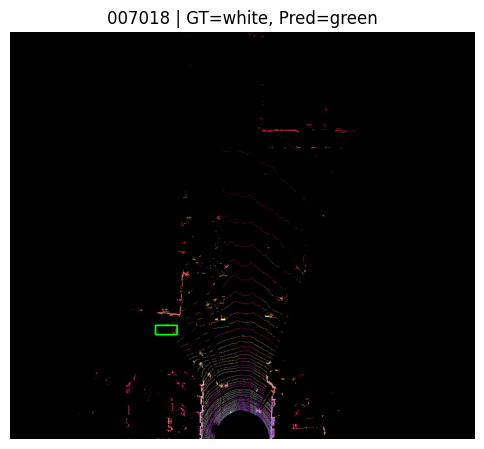

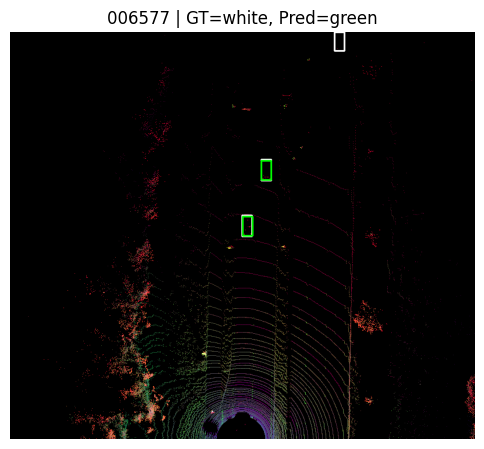

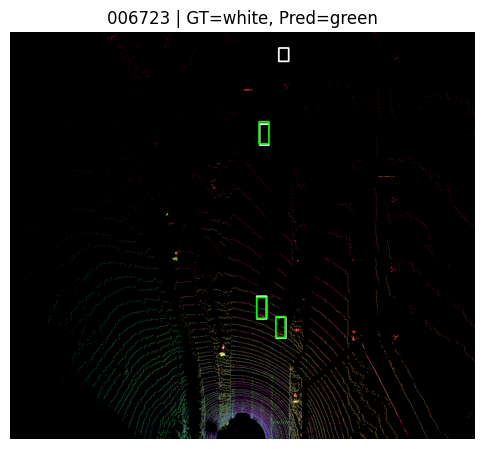

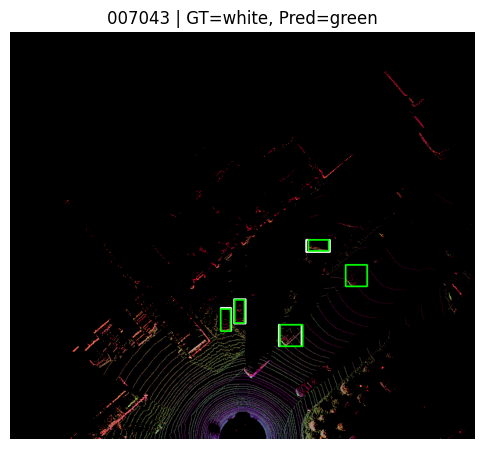

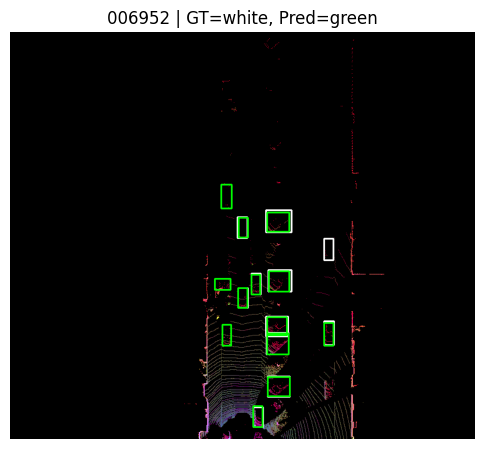

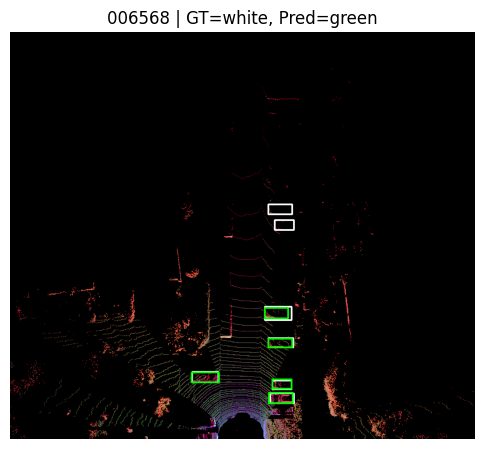

In [ ]:
def visualize_predictions(model, out_root, meta, n=6, conf=0.25):
    out_root = Path(out_root)
    img_dir = out_root / "images" / "test"
    lab_dir = out_root / "labels" / "test"

    H, W = meta["H"], meta["W"]
    test_imgs = sorted(img_dir.glob("*.png"))
    if len(test_imgs) == 0:
        print("No test images found.")
        return

    pick = np.random.choice(len(test_imgs), size=min(n, len(test_imgs)), replace=False)

    for idx in pick:
        img_path = test_imgs[idx]
        sid = img_path.stem
        gt_path = lab_dir / f"{sid}.txt"

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

        # GT boxes in white
        gt_boxes = yolo_label_file_to_xyxy_pixels(gt_path, W, H)
        vis = img.copy()
        for (x1,y1,x2,y2) in gt_boxes:
            cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (255,255,255), 2)

        preds = model.predict(str(img_path), conf=conf, verbose=False)
        if len(preds) > 0 and preds[0].boxes is not None:
            for box, c in zip(preds[0].boxes.xyxy.cpu().numpy(),
                              preds[0].boxes.cls.cpu().numpy().astype(int)):
                if c != 0:
                    continue
                x1,y1,x2,y2 = box
                cv2.rectangle(vis, (int(x1),int(y1)), (int(x2),int(y2)), (0,255,0), 2)

        plt.figure(figsize=(6,6))
        plt.title(f"{sid} | GT=white, Pred=green")
        plt.imshow(vis)
        plt.axis("off")
        plt.show()

visualize_predictions(model, out_root, meta, n=6, conf=0.25)